<div style="border-left: 4px solid #A2D2FF; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #ddeeff; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 35px;">Joint payoff forecast of tech stocks and a treasury note</h1> 
  </div>
  <div style="padding: 1em;">
  <p> 

<a><i class="fa fa-thumbtack" style="color:#A2D2FF; font-size:20px;"></i>  **Objective**</a>

This practical project is designed to provide hands-on experience in modeling and forecasting the market risk associated with the joint value of multiple stocks and a coupon bond. You will follow the first five steps of the Checklist and will be asked to apply the techniques that you believe are most suitable at each stage.

<a><i class="fa fa-book-open" style="color:#A2D2FF; font-size:20px;"></i>  **Background**</a>

Financial engineering includes all the steps of the “Checklist” that are necessary to begin any ex-ante risk assessment and any portfolio construction analysis. More specifically, it embodies all the techniques required to model both market risk and credit risk associated with every financial instrument into a portfolio, starting from available market data. It heavily draws from the theory of pricing, stochastic processes, time series analysis, and repricing. 

<a><i class="fa fa-folder" style="color:#A2D2FF; font-size:20px;"></i>  **Data**</a>

- Financial instruments:
    - Five stocks from US tech companies.
    - A Treasury note: a coupon-bearing bond maturing 10 years from the current date, paying a semi-annual coupon of 2%.
- Investment horizon: one business week from current time.
- Market data from 02/01/2018 to 02/01/2023. The latter is assumed as current time.
    - Daily closing prices and issued dividends, if any, of five stocks from yahoo finance (importable directly from yfinance, tickers = "MSFT", "AAPL", "NVDA", "AMZN", "GOOGL").
    - Daily key rates of yield-to-maturity associated with US-issued bonds, which we assume to have negligible credit risk (importable directly from pandas_datareader.data, database = "fred", tickers = "DGS2", "DGS5", "DGS10").
- Forecasting data
    - All imported data can be used. Current time is set equal to 02/01/2023.

</p></div></div>

<h1 style="font-weight: bold; font-size:14px; line-height:1.5em;"><i class="fa fa-gear" style="color:#A2D2FF; font-size:20px;"></i> Prepare environment</h1>

In [1]:
# Standard library
import os
import datetime
import warnings

# Numerical computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from ipywidgets import interact
from IPython.display import clear_output

# Data sources
from yfinance import download
import pandas_datareader.data as web
from pandas_datareader.fred import FredReader
from fredapi import Fred
import ipywidgets as widgets


# Statistics and econometrics
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.vector_ar.vecm import VECM, coint_johansen
from statsmodels.stats.diagnostic import acorr_ljungbox
from arpym.conditional_fp import conditional_fp
# Unit root tests
from arch.unitroot import ADF, KPSS

# Volatility models
from arch import arch_model

# Automatic ARIMA selection
from pmdarima.arima import auto_arima

# ARPM invariance tests
from arpym.invariance_test_ellipsoid import invariance_test_ellipsoid
from arpym.invariance_test_ks import invariance_test_ks

# Widgets
from ipywidgets import Dropdown, interact

# Random utilities
from numpy.random import rand

# Settings
SEED = 123

np.random.seed(SEED)
warnings.filterwarnings("ignore")


<div style="border-left: 4px solid #A2D2FF; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #ddeeff; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;"><i class="fa fa-code" style="color:#A2D2FF; font-size:20px;"></i> Task 1: Data exploration and market risk drivers</h1> 
  </div>
  <div style="padding: 1em;">
  <p>

- Download the stock prices and key rates.
- Plot the time series of stock prices and the time series of key rates. Discuss whether stock prices and yields can be used as market risk drivers. If not, transform the data into appropriate market risk drivers and justify your choices.

</p></div></div>

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed


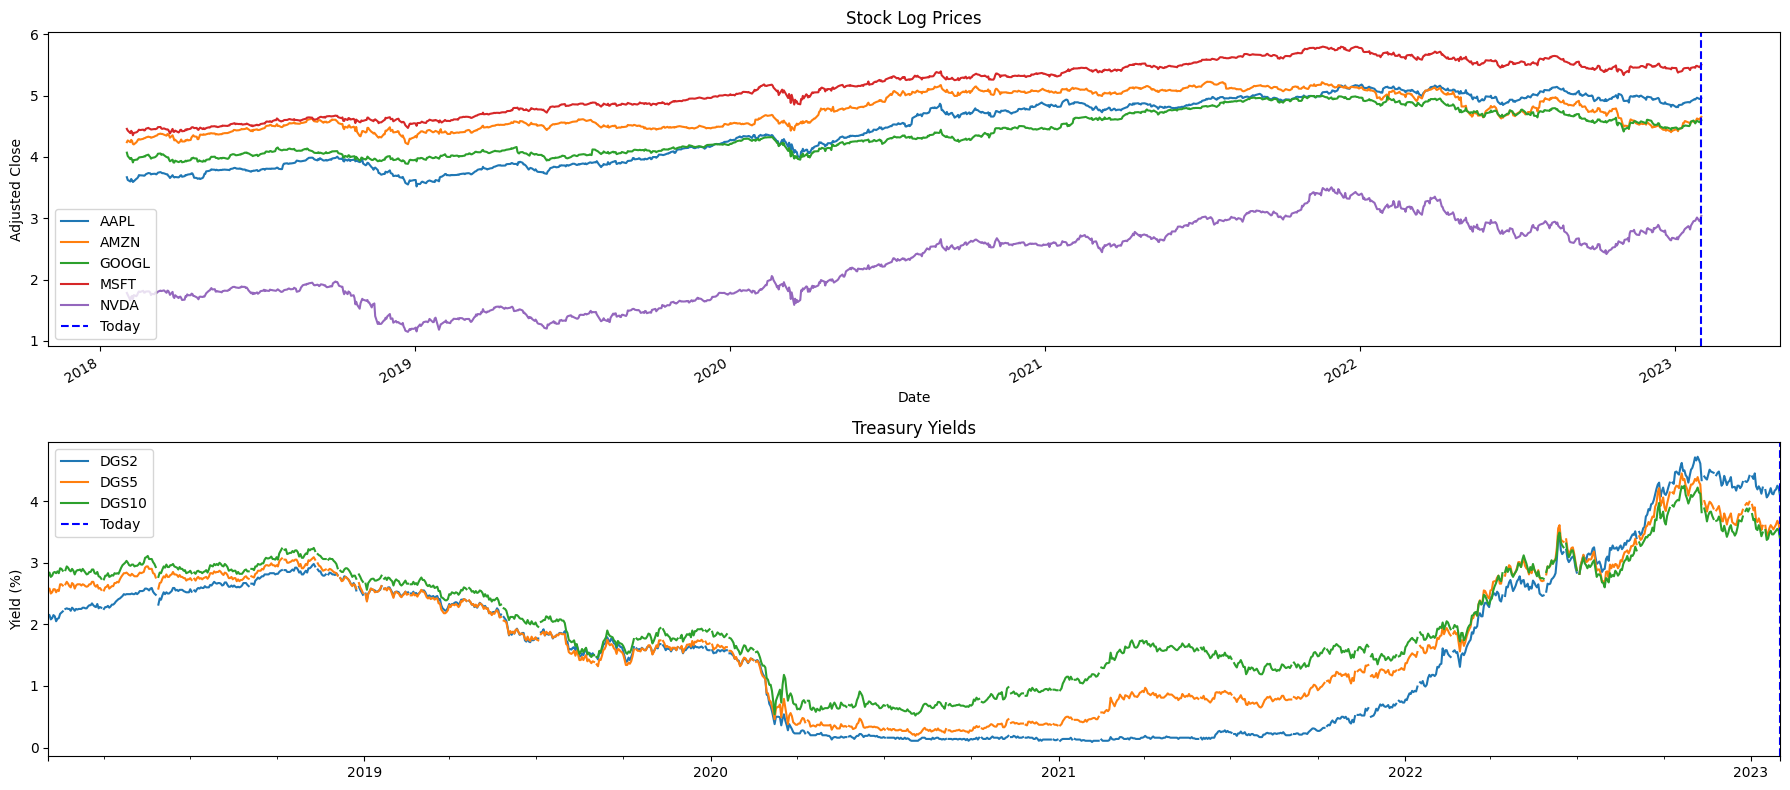

In [2]:
# stock
# train data
start_df = datetime.date(2018, 2, 1)
end_df = datetime.date(2023, 2, 2)
df_stock = download(["MSFT", "AAPL", "NVDA", "AMZN", "GOOGL"], start_df, end_df, auto_adjust = False)["Adj Close"]
df_log_stock = np.log(df_stock)
# test data
start_test = datetime.date(2023, 2, 2)
end_test = datetime.date(2023, 2, 15)
test_stock = download(["MSFT", "AAPL", "NVDA", "AMZN", "GOOGL"], start_test, end_test, auto_adjust = False)["Adj Close"]

# bond
fred = Fred(api_key="370f64f277027c07d1d977258e43fc6b")
dgs2 = pd.DataFrame(fred.get_series('DGS2'), columns = ['DGS2'])
dgs5 = pd.DataFrame(fred.get_series('DGS5'), columns = ['DGS5'])
dgs10 = pd.DataFrame(fred.get_series('DGS10'), columns = ['DGS10'])
# train
dgs2_train = dgs2[(dgs2.index >= '2018-02-01') & (dgs2.index <= '2023-02-01')]
dgs5_train = dgs5[(dgs5.index >= '2018-02-01') & (dgs5.index <= '2023-02-01')]
dgs10_train = dgs10[(dgs10.index >= '2018-02-01') & (dgs10.index <= '2023-02-01')]
df_bond = pd.concat([dgs2_train, dgs5_train, dgs10_train], axis = 1)
# test
dgs2_test = dgs2[(dgs2.index > '2023-02-01') & (dgs2.index <= '2023-02-15')]
dgs5_test = dgs5[(dgs5.index > '2023-02-01') & (dgs5.index <= '2023-02-15')]
dgs10_test = dgs10[(dgs10.index > '2023-02-01') & (dgs10.index <= '2023-02-15')]
df_bond_test = pd.concat([dgs2_test, dgs5_test, dgs10_test], axis = 1)


# Plot
fig, axes = plt.subplots(2, 1, figsize=(18, 8))
# ---- Stocks ----
df_log_stock.plot(ax=axes[0])
axes[0].axvline(x=datetime.date(2023, 2, 1),linestyle='--',color='blue',label='Today')
axes[0].set_title("Stock Log Prices")
axes[0].set_ylabel("Adjusted Close")
axes[0].legend()
# ---- Bonds ----
df_bond.plot(ax=axes[1])
axes[1].axvline(x=datetime.date(2023, 2, 1),linestyle='--',color='blue',label='Today')
axes[1].set_title("Treasury Yields")
axes[1].set_ylabel("Yield (%)")
axes[1].legend()
plt.tight_layout()
plt.show()

The time horizon is long(five years), and except for Amazon, other stocks pay dividends; the payoff is determined by the stock value and the dividend. The adjusted close price represents the stock's value plus reinvested dividends. But the constraint of non-negativity of the stock value and the high fluctuations in the value(risk is not homogeneous) mean that the adjusted close price can not be the market risk driver. Considering the market risk driver for equities, the log of the adjusted close price can resolve these issues. 
The government yield curve is the market risk driver for government bonds, and the yield curve fully determines the payoff of coupon bonds.

| Instrument    |    **Risk Driver**   |
|---------------|----------------------|
| "MSFT"  stock |     Log values       |
| "AAPL"  stock |     Log values       |
| "NVDA"  stock |     Log values       |
| "AMZN"  stock |     Log values       |
| "GOOGL" stock |     Log values       |
| coupon bond   | gmnt yield curve     |


<div style="border-left: 4px solid #A2D2FF; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #ddeeff; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;"><i class="fa fa-code" style="color:#A2D2FF; font-size:20px;"></i> Task 2: Market risk drivers modeling</h1> 
  </div>
  <div style="padding: 1em;">
  <p>

- Based on available data (time series length, missing data, etc.) and forecasting horizon (one business week from current time), construct a joint econometric model for the risk drivers detected at the previous point. Use the techniques that you feel are more appropriate, motivating your choices.
</p></div></div>

In [3]:
data = pd.concat([df_log_stock, df_bond], axis = 1)
data = data.dropna()
df = data.diff()
df = df.dropna()

def run_test(var):
    rho, conf_int = invariance_test_ellipsoid(np.array(df[var]),l_bar=5, conf_lev=0.95,  fit=0,r=2,title=f'Invariance test {var}')
    significant = np.any((rho > conf_int[1]) |(rho < conf_int[0]))
    if significant:
        print("Reject H0: invariant is not white noise.")
    else:
        print("Cannot reject H0: invariant behaves as white noise.")
    z_ks, z = invariance_test_ks(np.array(df[var]),conf_lev=0.95)
    if z_ks > z:
        print("Reject H0: invariant is not a strong white-noise process.")
    else:
        print("Cannot reject H0: invariant may be a strong white-noise process.")
interact(run_test, var =df.columns);

interactive(children=(Dropdown(description='var', options=('AAPL', 'AMZN', 'GOOGL', 'MSFT', 'NVDA', 'DGS2', 'D…

In [4]:
# univariate model identification : to fit an econometric model (a stochastic process) and extract the realized invariants (i.i.d. shocks) for each single market risk driver
def arma_mode_search(col):
    uni_model = auto_arima(data[col],  start_p=0,start_d=0, start_q=0,
    max_p=3, max_d=3,max_q=3, trace=True,with_intercept=False, return_valid_fits=True,)
    print(f"Selected variable: {col}")

def arma_model(col, p,d,q):
    appl_arma = SARIMAX(data[col], order=(p, d, q), trend="c").fit(disp=False) 
    print(appl_arma.summary().tables[1])
    eps = appl_arma.resid
    abs_eps = np.abs(eps)
    fig = appl_arma.plot_diagnostics(figsize=(18,7))
    axes = fig.axes
    axes[0].set_title("Standardized Residuals")
    axes[1].set_title("Residual Histogram")
    axes[2].set_title("Normal Q-Q Plot")
    axes[3].set_title("Correlogram")
    plt.tight_layout()
    plt.show()
    fig, axes = plt.subplots(figsize = (18,3))
    plt.plot(abs_eps[2:])
    plt.show()


interact(arma_mode_search, col =data.columns);

interactive(children=(Dropdown(description='col', options=('AAPL', 'AMZN', 'GOOGL', 'MSFT', 'NVDA', 'DGS2', 'D…

In [5]:
interact(arma_model, col=list(data.columns),p=(0, 4),d=(0, 3),q=(0, 3));

interactive(children=(Dropdown(description='col', options=('AAPL', 'AMZN', 'GOOGL', 'MSFT', 'NVDA', 'DGS2', 'D…

The standardized residuals and absolute residual graphs show there is a period where the variation is higher than other periods.we can see there are pockets of time in the whole period where the movement of returns are more volatile than others. These high volatility pockets do not spread randomly during the whole time period. We call these volatility clustering. We notice that there is autocorrelation of asset returns. A highly volatile return one day would be followed by another highly volatile return the next day. It means that the past volatilities will still have an impact on today's volatility. The highly volatile periods tend to group together. The ACF plots are show that some lags are significant. From the QQ plot for the residuals, we can see the residuals are not normally distributed since the plot shows fat tails on both ends.

In [6]:
# garch on first difference of log price
db_invariants = np.zeros((df.shape[0], len(df.columns)))
db_garch_param = {}; 
for j, i in enumerate(df.columns):
    garch = arch_model(df[i], vol='garch', p=1, o=0, q=1, rescale=False)  # define GARCH(1,1) model
    garch_fitted = garch.fit(disp='off')  # fit GARCH(1,1)
    par = garch_fitted._params  # parameters
    sigma = garch_fitted._volatility # realized conditional volatility
    sigma2 = sigma**2  # realized conditional variance
    eps = garch_fitted.std_resid  # GARCH(1,1) invariants
    # store invariants, GARCH(1,1) parameters and next-step function
    db_invariants[:, j] = eps
    db_garch_param[j] = dict(zip(['mu', 'c', 'a', 'b'] + 
                                 ['sig2_' + str(t).zfill(3) for t in range(df.shape[0])], np.append(par, sigma2)))


In [7]:
invariants = pd.DataFrame(db_invariants, columns=df.columns)
def run_test(var):

    rho, conf_int = invariance_test_ellipsoid( np.array(invariants[var]),l_bar=5, conf_lev=0.95,fit=0,r=2,title=f'Invariance test on {var}')
    significant = np.any((rho > conf_int[1]) |(rho < conf_int[0]))
    if significant:
        print("Reject H0: invariant is not white noise.")
    else:
        print("Cannot reject H0: invariant behaves as white noise.")
    z_ks, z = invariance_test_ks(np.array(invariants[var]), conf_lev=0.95)
    if z_ks > z:
        print("Reject H0: invariant is not a strong white-noise process.")
    else:
        print("Cannot reject H0: invariant may be a strong white-noise process.")
interact(run_test, var=invariants.columns);

interactive(children=(Dropdown(description='var', options=('AAPL', 'AMZN', 'GOOGL', 'MSFT', 'NVDA', 'DGS2', 'D…

To find the multivariate model risk, I use the [Decision Tree Figure](https://www.arpm.co/lab/redirect.php?permalink=fig0200-decision-tree) to choose the approach. In this project, the data  is clean, it does not have a small dimension, so we first check for cointegration, if the data is cointegrated,we use mean-covariance approach otherwise since the test horizon is seven dayas and respect for thatt , time series is long we choose the probabilistic approach. 
Based on [Mean Covariance Approach](https://www.arpm.co/lab/redirect.php?permalink=fig-multiv-cont-quest-for-invariance) first , we check if the data is trend stationary or not: 

In [8]:
from arch.unitroot import ADF
# trend="ct" → constant + linear trend included in the test regression.
aapl_adf = ADF(data.AAPL, trend="ct", method="bic")
amzn_adf = ADF(data.AMZN, trend="ct", method="bic")
googl_adf = ADF(data.GOOGL, trend="ct", method="bic")
msft_adf = ADF(data.MSFT, trend="ct", method="bic")
nvda_adf = ADF(data.NVDA, trend="ct", method="bic")
dgs2_adf = ADF(data.DGS2, trend="ct", method="bic")
dgs5_adf = ADF(data.DGS5, trend="ct", method="bic")
dgs10_adf = ADF(data.DGS10, trend="ct", method="bic")



pd.DataFrame(
    {"APPL": (aapl_adf.stat, aapl_adf.critical_values["5%"]),
     "| AMZN": (amzn_adf.stat, amzn_adf.critical_values["5%"]),
     "| GOOGL ": ( googl_adf.stat,googl_adf.critical_values["5%"]),
     "| MSFT": (msft_adf.stat, msft_adf.critical_values["5%"]),
     "| NVDA": ( nvda_adf.stat,nvda_adf.critical_values["5%"]),
     "| DGS2": (dgs2_adf.stat, dgs2_adf.critical_values["5%"]),
     "| DGS5": ( dgs5_adf.stat,dgs5_adf.critical_values["5%"]),
     "| DGS10": ( dgs10_adf.stat,dgs10_adf.critical_values["5%"]),
    },
    index=["ADF Test Statistic", "5% Critical Value"],
)


,APPL,| AMZN,| GOOGL,| MSFT,| NVDA,| DGS2,| DGS5,| DGS10
ADF Test Statistic,-1.427297,-1.405273,-1.531525,-1.314251,-1.768900,0.618271,-0.346105,-0.641936
5% Critical Value,-3.414017,-3.414014,-3.414017,-3.414017,-3.414017,-3.414014,-3.414014,-3.414014


- H₀: the series has a unit root (not trend-stationary).
- H₁: the series is trend-stationary.
Since none of the statistics are below the critical value, so fail to reject the unit-root null.
Therefore:There is no evidence that these series are trend-stationary, and I check for cointegration:

In [9]:
# Check whether time series are I(1)
aapl_adf = ADF(df.AAPL, trend="c", method="bic")
amzn_adf = ADF(df.AMZN, trend="c", method="bic")
googl_adf = ADF(df.GOOGL, trend="c", method="bic")
msft_adf = ADF(df.MSFT, trend="c", method="bic")
nvda_adf = ADF(df.NVDA, trend="c", method="bic")
dgs2_adf = ADF(df.DGS2, trend="c", method="bic")
dgs5_adf = ADF(df.DGS5, trend="c", method="bic")
dgs10_adf = ADF(df.DGS10, trend="c", method="bic")

pd.DataFrame(
    {"APPL": (aapl_adf.stat, aapl_adf.critical_values["5%"]),
     "| AMZN": (amzn_adf.stat, amzn_adf.critical_values["5%"]),
     "| GOOGL ": ( googl_adf.stat,googl_adf.critical_values["5%"]),
     "| MSFT": (msft_adf.stat, msft_adf.critical_values["5%"]),
     "| NVDA": ( nvda_adf.stat,nvda_adf.critical_values["5%"]),
     "| DGS2": (dgs2_adf.stat, dgs2_adf.critical_values["5%"]),
     "| DGS5": ( dgs5_adf.stat,dgs5_adf.critical_values["5%"]),
     "| DGS10": ( dgs10_adf.stat,dgs10_adf.critical_values["5%"]),
    },
    index=["ADF Test Statistic", "5% Critical Value"],
)


,APPL,| AMZN,| GOOGL,| MSFT,| NVDA,| DGS2,| DGS5,| DGS10
ADF Test Statistic,-39.422256,-36.333332,-39.327482,-43.386898,-38.423085,-35.269700,-35.001642,-34.814157
5% Critical Value,-2.863861,-2.863861,-2.863861,-2.863861,-2.863861,-2.863861,-2.863861,-2.863861


First difference is stationary, so timeseries are I(1).

In [10]:
model = VAR(data)
x = model.select_order(maxlags=5, trend="c")
x.summary()

,AIC,BIC,FPE,HQIC
0,-28.07,-28.03,6.461e-13,-28.06
1,-63.12,-62.82*,3.880e-28,-63.00*
2,-63.17*,-62.61,3.688e-28*,-62.96
3,-63.14,-62.32,3.793e-28,-62.83
4,-63.11,-62.03,3.890e-28,-62.71
5,-63.09,-61.74,3.985e-28,-62.58


In [11]:
diff_mod = VAR(data)
diff_mod_var = diff_mod.fit( maxlags=None,ic=None, method="ols", trend="c", verbose=True,)
diff_mod_var.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 26, Jun, 2026
Time:                     23:42:41
--------------------------------------------------------------------
No. of Equations:         8.00000    BIC:                   -62.7964
Nobs:                     1248.00    HQIC:                  -62.9811
Log likelihood:           25274.9    FPE:                3.97517e-28
AIC:                     -63.0923    Det(Omega_mle):     3.75310e-28
--------------------------------------------------------------------
Results for equation AAPL
              coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------
const            0.036002         0.028682            1.255           0.209
L1.AAPL          0.982284         0.008837          111.152           0.000
L1.AMZN         -0.004783         0.007048           -0.679           0.497
L1.GO

In [12]:
# Johansen Trace Test Result 

jtest = coint_johansen(data, det_order=0, k_ar_diff=1)

# Print the results
print(f"Eigenvalues of VECM coefficient matrix : {jtest.eig}\n")

pd.DataFrame(
    {
        "Test statistic": jtest.trace_stat,
        "Critical values (90%)": jtest.trace_stat_crit_vals[:, 0],
        "Critical values (95%)": jtest.trace_stat_crit_vals[:, 1],
        "Critical values (99%)": jtest.trace_stat_crit_vals[:, 2],
    },
)

Eigenvalues of VECM coefficient matrix : [0.06233163 0.02719477 0.01839209 0.01262564 0.00971528 0.0059655
 0.00532028 0.00020834]



,Test statistic,Critical values (90%),Critical values (95%),Critical values (99%)
0,180.177364,153.6341,159.5290,171.0905
1,99.921765,120.3673,125.6185,135.9825
2,65.540246,91.1090,95.7542,104.9637
3,42.391779,65.8202,69.8189,77.8202
4,26.547370,44.4929,47.8545,54.6815
5,14.373183,27.0669,29.7961,35.4628
6,6.911927,13.4294,15.4943,19.9349
7,0.259829,2.7055,3.8415,6.6349


We use %5 as our decision point, for rank 1, test statistics is less than critical value(95%), we cannot reject null hypothesis so there is one linear combination of series variables that is stationary.

In [13]:
# VECM model
vecm_model = VECM(endog=data, k_ar_diff=1, deterministic="ci").fit()
print(vecm_model.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation AAPL
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.AAPL       -0.0610      0.047     -1.300      0.193      -0.153       0.031
L1.AMZN        0.0310      0.040      0.770      0.441      -0.048       0.110
L1.GOOGL      -0.0499      0.053     -0.933      0.351      -0.155       0.055
L1.MSFT       -0.1344      0.062     -2.164      0.030      -0.256      -0.013
L1.NVDA        0.0624      0.028      2.251      0.024       0.008       0.117
L1.DGS2        0.0056      0.030      0.184      0.854      -0.054       0.065
L1.DGS5       -0.0338      0.048     -0.707      0.480      -0.128       0.060
L1.DGS10       0.0125      0.033      0.374      0.708      -0.053       0.078
Det. terms outside the coint. relation & lagged endog. parameters for equation AMZN
                 coef    std err          

S = -2.8131 + AAPL + 1.0111 *AMZN -0.2568*GOOGL -0.8433*MSFT -0.4197  * NVDA -0.7955 * DGS2 + 2.0964 * DGS5 -1.2037 * DGS10

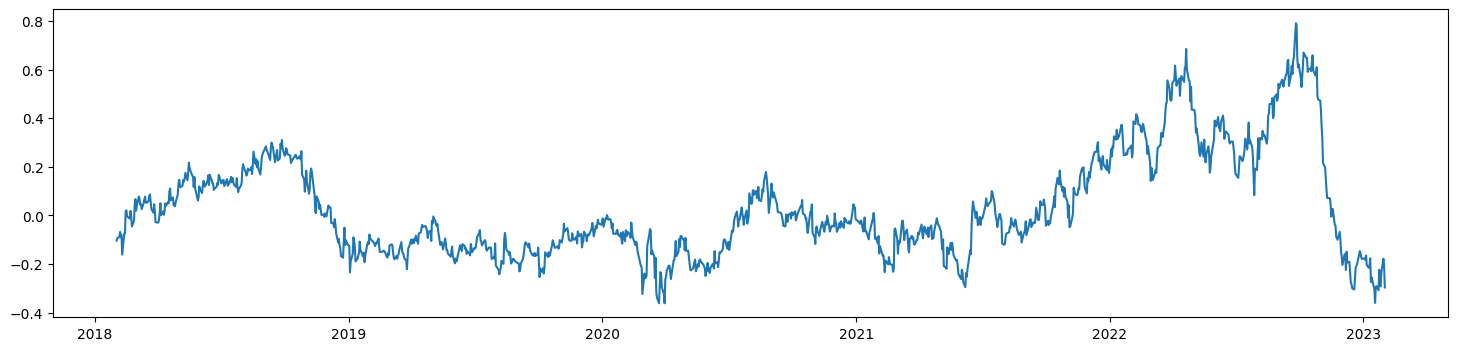

In [14]:
# Time Plot for Deviation from Long-Term Equilibrium
"""
The precise coefficients of the linear combination are in:
vecm_model.const_coint and vecm_model.beta
S =  -2.8131 + AAPL + 1.0111 AMZN -0.2568GOOGL -0.8433*MSFT -0.4197 * NVDA -0.7955 * DGS2 + 2.0964 * DGS5 -1.2037 * DGS10
"""
S = (
    vecm_model.const_coint[0][0]
    + vecm_model.beta[0][0] * data.AAPL
    + vecm_model.beta[1][0] * data.AMZN
    + vecm_model.beta[2][0] * data.GOOGL
    + vecm_model.beta[3][0] * data.MSFT
    + vecm_model.beta[4][0] * data.NVDA
    + vecm_model.beta[5][0] * data.DGS2
    + vecm_model.beta[6][0] * data.DGS5
    + vecm_model.beta[7][0] * data.DGS10
)
fig = plt.figure(figsize=(18, 4))
plt.plot(S)
plt.show()

In [15]:
# ADF Test Result for Deviation from Long-Term Equilibrium
S_adf = ADF(S, trend="n", method="bic")
print("Augmented Dickey-Fuller Unit Root Test\n", S_adf.regression.summary())
print("\nTest statistics and critical values: \n", S_adf)

Augmented Dickey-Fuller Unit Root Test
                                  OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.016
Model:                            OLS   Adj. R-squared (uncentered):              0.015
Method:                 Least Squares   F-statistic:                              10.21
Date:                Fri, 26 Jun 2026   Prob (F-statistic):                    4.01e-05
Time:                        23:43:30   Log-Likelihood:                          2397.1
No. Observations:                1247   AIC:                                     -4790.
Df Residuals:                    1245   BIC:                                     -4780.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-

we can see that we easily reject that the deviation has a unit root because the test statistic (-2.649) is below 5% critical value (-1.94).


In [16]:
eps = vecm_model.resid
for i in range(eps.shape[1]):
    print(f"eps{i}")
    rho, conf_int = invariance_test_ellipsoid(np.array(eps[:,2]), l_bar=5, conf_lev=0.95, fit=0,r=2, plot_test=False)
    significant = np.any((rho > conf_int[1]) |(rho < conf_int[0]))
    if significant:
        print("Reject H0: invariant is not white noise.")
    else:
        print("Cannot reject H0: invariant behaves as white noise.")
    
    z_ks, z = invariance_test_ks(np.array(eps[:,2]),conf_lev=0.95,plot_test=False)
    if z_ks > z:
        print("Reject H0: invariant is not a strong white-noise process.")
    else:
        print("Cannot reject H0: invariant may be a strong white-noise process.")

eps0
Cannot reject H0: invariant behaves as white noise.
Cannot reject H0: invariant may be a strong white-noise process.
eps1
Cannot reject H0: invariant behaves as white noise.
Cannot reject H0: invariant may be a strong white-noise process.
eps2
Cannot reject H0: invariant behaves as white noise.
Cannot reject H0: invariant may be a strong white-noise process.
eps3
Cannot reject H0: invariant behaves as white noise.
Cannot reject H0: invariant may be a strong white-noise process.
eps4
Cannot reject H0: invariant behaves as white noise.
Cannot reject H0: invariant may be a strong white-noise process.
eps5
Cannot reject H0: invariant behaves as white noise.
Cannot reject H0: invariant may be a strong white-noise process.
eps6
Cannot reject H0: invariant behaves as white noise.
Cannot reject H0: invariant may be a strong white-noise process.
eps7
Cannot reject H0: invariant behaves as white noise.
Reject H0: invariant is not a strong white-noise process.


<div style="padding:15px; border-radius:8px;">
  <b><i class="fa fa-pen" style="color:#A2D2FF; font-size:18px;"> </i>  Explain your insights</b><br><br>
</div>

In Task 2, we proceed step by step to become familiar with the data and to identify an appropriate univariate model. First, we examine stationarity and find that the first-differenced series is not stationary. We then apply the `auto_arima` function to select a suitable univariate specification. However, diagnostic analysis of the standardized and absolute residuals reveals periods of elevated variability compared to the rest of the sample. This indicates that volatility is not constant over time. Instead, we observe distinct episodes where return fluctuations are significantly higher. These high-volatility periods are clustered rather than randomly distributed, a phenomenon known as volatility clustering. Based on these findings, a GARCH-type model is appropriate to capture conditional heteroskedasticity.

For the multivariate risk modeling, we follow a decision-tree approach to select the appropriate framework. Given that the dataset is clean, all series have equal length, and the dimensionality is not small, we begin by testing for cointegration. Since the data are not trend-stationary (all test statistics fail to reject the unit-root null hypothesis), we conclude that the series are integrated of order one, I(1). We therefore proceed to cointegration analysis. 
Next, we determine the lag order and estimate a VAR framework and then perform  the Johansen cointegration test. The Johansen trace test indicates that, at the 5% significance level, the test statistic for rank 1 is below the critical value. Hence, we fail to reject the null hypothesis and conclude that there exists one cointegrating relationship among the variables.

The estimated cointegrating equation is:

S = -2.8131 + AAPL + 1.0111·AMZN − 0.2568·GOOGL − 0.8433·MSFT − 0.4197·NVDA − 0.7955·DGS2 + 2.0964·DGS5 − 1.2037·DGS10

To validate the long-run equilibrium relationship, we apply an ADF test on the residuals. The test statistic (-2.649) is below the 5% critical value (-1.94), allowing us to reject the unit root hypothesis. This confirms that the deviation from the long-run equilibrium is stationary.


<div style="border-left: 4px solid #A2D2FF; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #ddeeff; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;"><i class="fa fa-code" style="color:#A2D2FF; font-size:20px;"></i> Task 3: Forecasting</h1> 
  </div>
  <div style="padding: 1em;">
  <p>

- Based on the econometric model chosen at the previous task, forecast the joint distribution of the risk drivers one business week from current time, motivating your choice. For simplicity, you may use the same data used for the model fit.
- Plot the forecast distribution of one risk driver associated with one of the stocks, and the forecast distribution of one risk driver associated with the yield curve.
</p></div></div>

[*********************100%***********************]  1 of 1 completed


Effective number of scenarios: 514


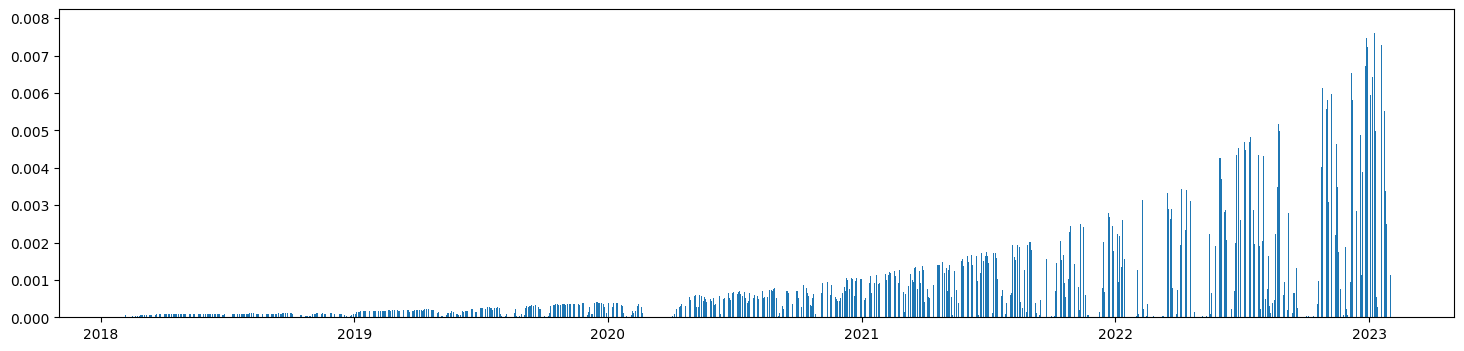

In [17]:
# flexible probability
vix_dt = download('^VIX', start=start_df, end=end_df, auto_adjust=False)['Adj Close']
vix_dt = vix_dt.loc[vix_dt.index.isin(data.index)]
vix_dt = np.log(vix_dt).diff().dropna()
vix_data = vix_dt.values

# perform smoothing
c_vix_smooth = np.zeros(vix_data.shape[0])
tau_smooth_hl = 21  # half-life for smoothing 
for t in range(vix_data.shape[0]):
    # probabilities
    p_w = np.exp(-np.log(2)/tau_smooth_hl*np.arange(0, t + 1))[::-1].reshape(-1)  
    # sum of probabilities
    gamma_w = sum(p_w)
    # risk factor
    c_vix_smooth[t] = (p_w/gamma_w)@vix_data.reshape(vix_data.shape[0], -1)[0:t + 1, :]  

# perform scoring
c_vix_score = np.zeros(c_vix_smooth.shape[0])
tau_score_hl = 105  # half-life for scoring 
for t in range(1, c_vix_smooth.shape[0]):
    # probabilities
    p_w = np.exp(-np.log(2)/tau_score_hl*np.arange(0, t + 1))[::-1].reshape(-1)
    # sum of probabilities
    gamma_w = sum(p_w)
    # exponentially weighted moving average
    ewma_t_x = (p_w/gamma_w)@c_vix_smooth[0:t + 1].reshape(-1,1)
    # exponentially weighted moving standard deviation
    ewm_sd_t = np.sqrt(((c_vix_smooth[0:t + 1].reshape(-1,1) - ewma_t_x).T*(p_w/gamma_w))@\
                       (c_vix_smooth[0:t + 1].reshape(-1,1) - ewma_t_x))
    # risk factor
    c_vix_score[t] = (c_vix_smooth[t] - ewma_t_x)/ewm_sd_t  
  

t_bar = vix_data.shape[0]
tau_prior_hl = 180  # prior half-life 
p_tau_hl_prior = np.exp(-(np.log(2)/tau_prior_hl)*abs(t_bar - np.arange(0, t_bar)))  # prior probabilities
p_tau_hl_prior = p_tau_hl_prior/sum(p_tau_hl_prior)  # rescaled probabilities
alpha = 0.7  # leeway 
z_star = -0.39  # target value 
p_t = conditional_fp(c_vix_score, z_star, alpha, p_tau_hl_prior)  # posterior probabilities

ens_p = np.exp(-p_t[p_t > 0]@np.log(p_t[p_t > 0])) 
print('Effective number of scenarios:', int(ens_p))

######################## plot ########################
# time and state conditioning flexible probabilities
fig, axes = plt.subplots(1,1, figsize = (18,4))
plt.bar(vix_dt.index, p_t)
plt.show()

In [18]:
# vecm model 
alpha = vecm_model.alpha
beta  = vecm_model.beta
gamma = vecm_model.gamma
eps   = vecm_model.resid

t_0 = end_df # current time
d_bar = data.shape[1]
delta_t = 5 # forecast five business day
n_eps = len(eps)
p_t = p_t[-len(eps):]
j_bar = 10000  # number of projection scenarios 

# log price difference, df is the log price difference
dx_t = np.empty((j_bar, delta_t + 1, d_bar)) # for each instrument have (10000 * 7) simulation for 10000 scenarios per day
dx_t[:, 0, :] = df.iloc[-1, :]  # current values of increments x is the difference of log price

# initialize forecast risk drivers
x_t = np.empty((j_bar, delta_t + 1, d_bar))
x_t[:, 0, :] = data.iloc[-1, :]  # risk drivers at current time

for m in range(delta_t):
    # bootstrap routine
    # subintervals
    s = np.r_[np.array([0]), np.cumsum(p_t)] 
    s[-1] = 1.0
    
    # scenarios
    u = rand(j_bar)  # uniform scenario
    ind = np.digitize(u , bins=s) - 1  # categorical scenarios
    eps_proj = eps[ind, :]  # shock scenarios
    ec_term = (x_t[:,m,:] @ beta) @ alpha.T
    ar_term = (dx_t[:,m,:] @ gamma.T)
    dx_t[:,m+1,:] = (ec_term + ar_term+ eps_proj)
    x_t[:,m+1,:] = (x_t[:,m,:]+ dx_t[:,m+1,:])

p_scenario = np.ones(j_bar)/j_bar  # projection scenario probabilities


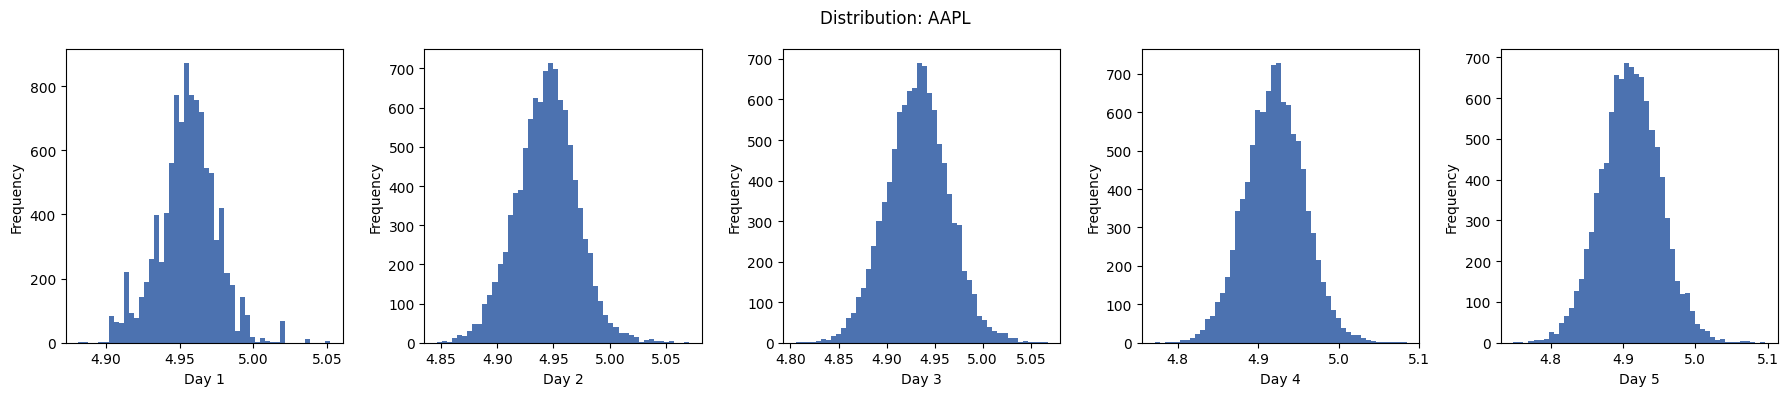

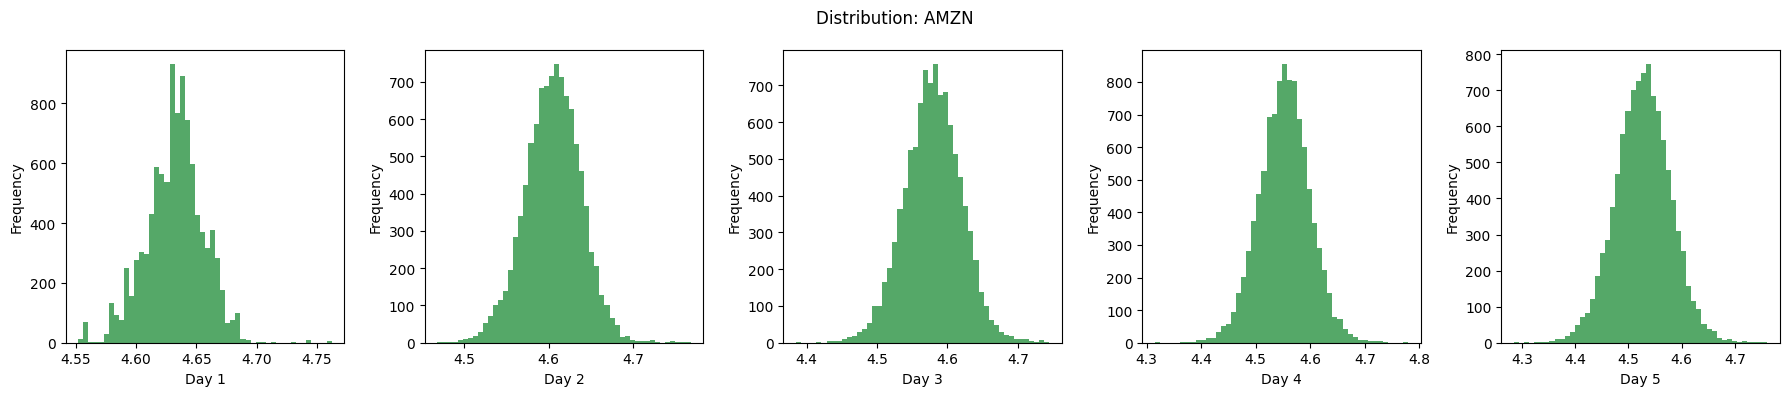

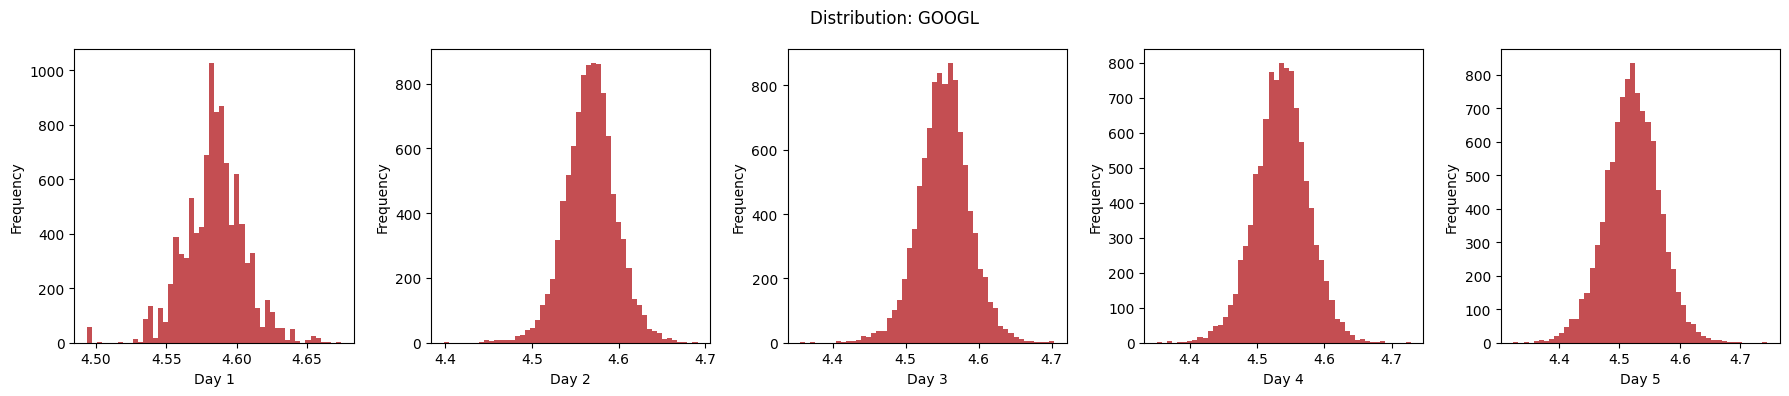

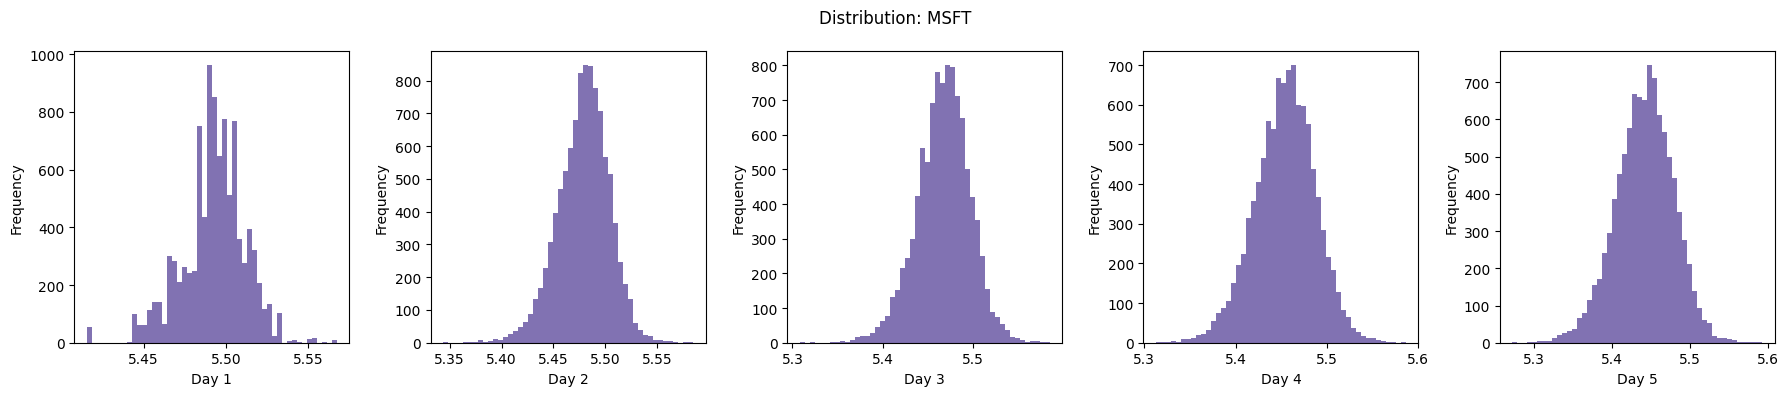

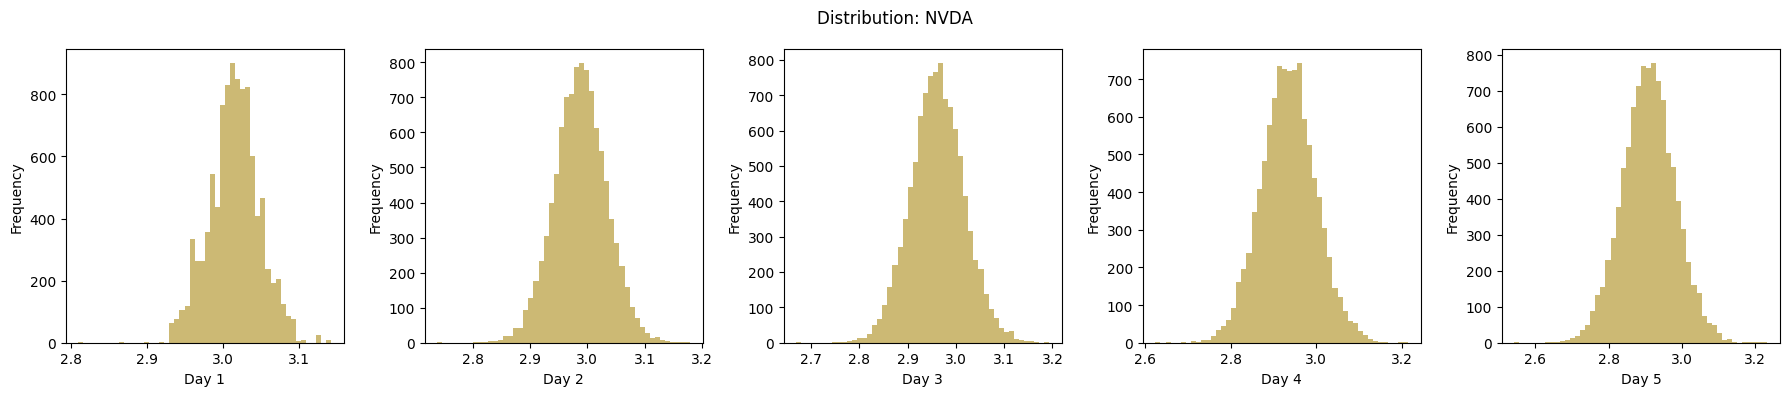

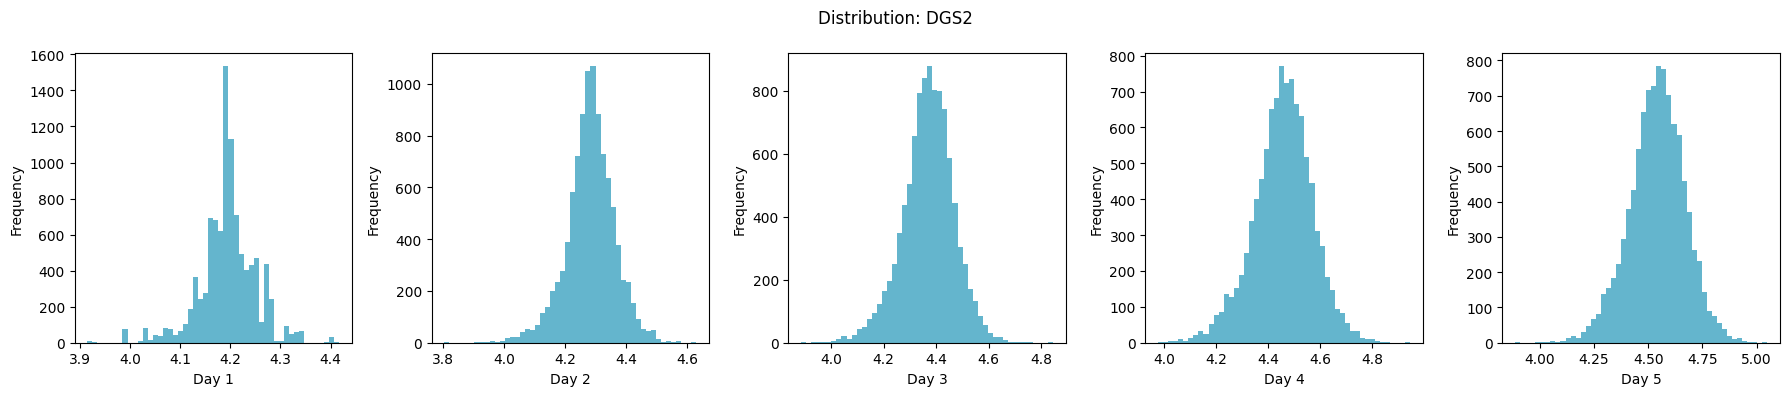

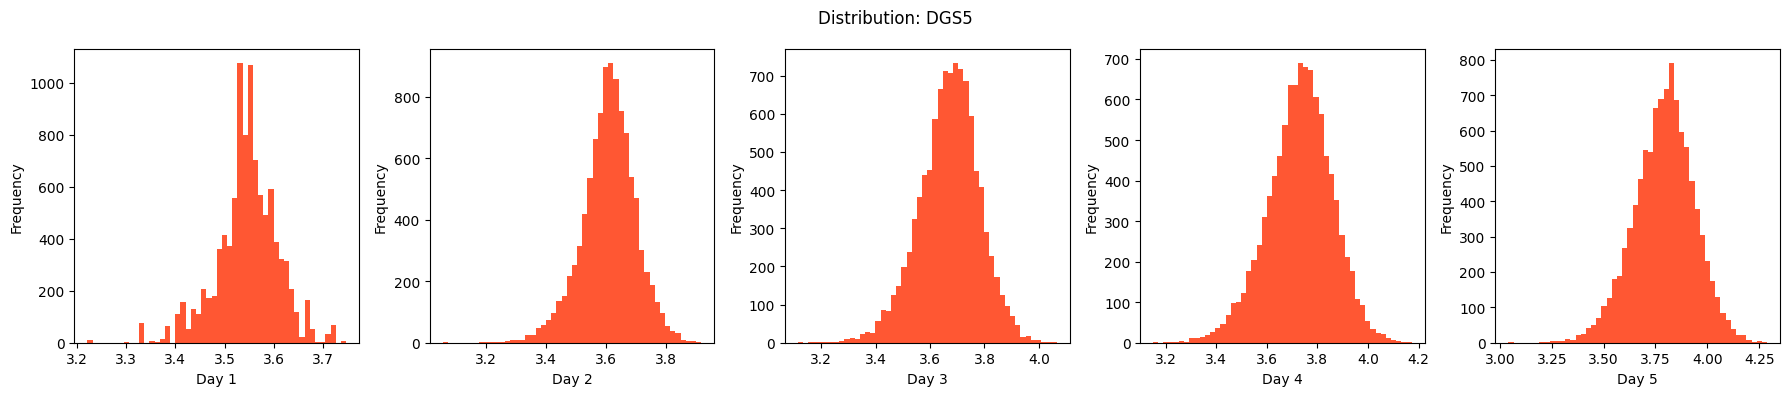

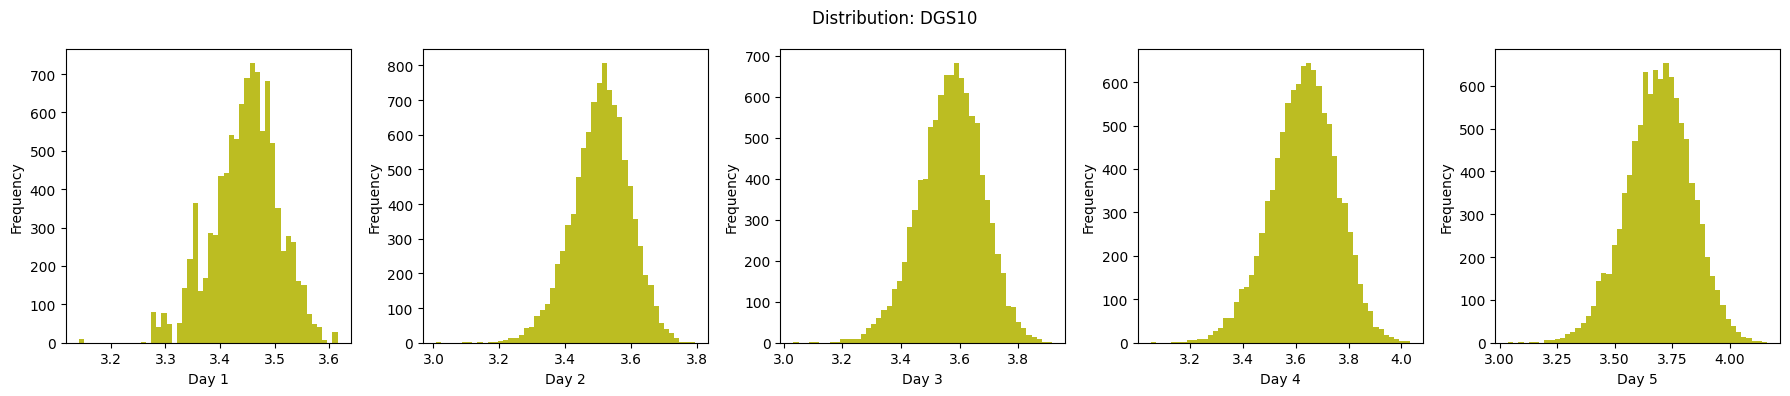

In [19]:
colors = ["#4C72B0", "#55A868", "#C44E52","#8172B2","#CCB974","#64B5CD", "#FF5733",'#bcbd22' ]
def plot_dist(data, i, stock):
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))

    for t in range(1,6):  
        axes[t-1].hist(data[:, t, i], color = colors[i], bins=50)
        axes[t-1].set_xlabel(f"Day {t}")
        axes[t-1].set_ylabel("Frequency")

    fig.suptitle(f"Distribution: {stock}")
    plt.tight_layout()
    plt.show()

for i, j in enumerate(df.columns):
    plot_dist(x_t, i, j)


<div style="border-left: 4px solid #A2D2FF; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #ddeeff; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;"><i class="fa fa-code" style="color:#A2D2FF; font-size:20px;"></i> Task 4: Repricing</h1> 
  </div>
  <div style="padding: 1em;">
  <p>

- Based on the forecast distribution and the models chosen at the previous steps, perform joint repricing of all the stocks and the bonds at the investment horizon.
- Plot the distribution of the payoff of each instrument at the investment horizon.
</p></div></div>

the horizon t short enough to not include earned cashflows

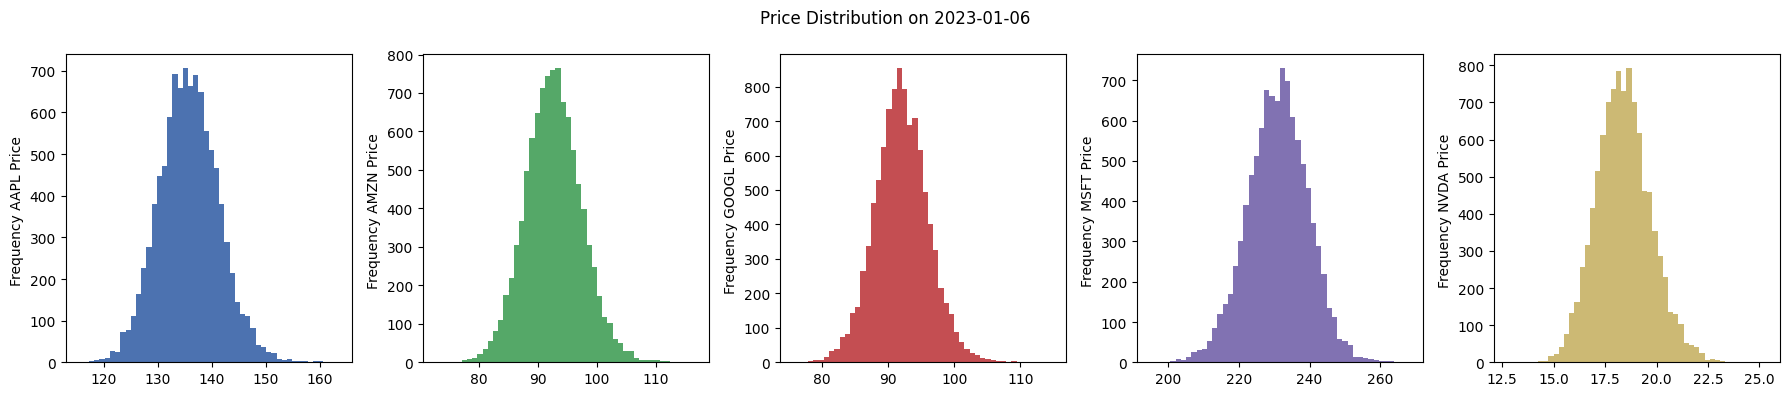

In [27]:
# payoff scenario at the horizon
colors = ["#4C72B0", "#55A868", "#C44E52","#8172B2","#CCB974" ]

n_stocks = 5
n_bar = x_t.shape[0]  # number of Monte Carlo simulations
pi_t = np.zeros((n_bar, n_stocks))
for n in range(n_stocks):
    pi_t[:, n] = np.exp(x_t[:, -1, n])

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, j in enumerate(df.columns[:5]):  
    axes[i].hist(pi_t[:, i], color = colors[i], bins=50)
    axes[i].set_ylabel(f"Frequency {j} Price ")
fig.suptitle("Price Distribution on 2023-01-06")
plt.tight_layout()
plt.show()
   

In [31]:
j_bar = x_t.shape[0]  # number of Monte Carlo simulations
t_bar = x_t[:,:,-3].shape[1]  # number of times to maturity
# current key rates
y = x_t[:,:,-3:]/100  # key rates scenarios
y_0 = y[0, 0, :]  # current key rates


lambda_ns = 0.0609

tau = np.array([2,5,10])      # maturities
L = np.zeros((3,3))

for i,t in enumerate(tau):
    f1 = (1-np.exp(-lambda_ns*t))/(lambda_ns*t)
    f2 = f1 - np.exp(-lambda_ns*t)
    L[i] = [1,f1,f2]
beta = np.linalg.solve(L,y_0)

beta0,beta1,beta2 = beta    
#Nelson–Siegel spot-rate function
def ns_rate(t,beta0,beta1,beta2,lamb=lambda_ns):
    f1 = (1-np.exp(-lamb*t))/(lamb*t)
    f2 = f1 - np.exp(-lamb*t)
    return beta0 + beta1*f1 + beta2*f2

def price_bond(beta0,beta1,beta2):
    face = 1
    coupon = 0.02
    freq = 2
    cashflow = face*coupon/freq
    price = 0
    for k in range(1,21):
        t = k/freq
        r = ns_rate(t,beta0,beta1,beta2)
        df = np.exp(-r*t)
        cf = cashflow
        if k==20:
            cf += face
        price += cf*df
    return price

P0 = price_bond(beta0,beta1,beta2)
bp = 0.0001

current = y_0

KRD = np.zeros(3)

for i in range(3):
    bumped = current.copy()
    bumped[i] += bp
    # Fit NS again
    L = np.zeros((3,3))
    for j,t in enumerate(tau):
        f1 = (1-np.exp(-lambda_ns*t))/(lambda_ns*t)
        f2 = f1 - np.exp(-lambda_ns*t)
        L[j] = [1,f1,f2]
    beta_bumped = np.linalg.solve(L,bumped)
    P_bumped = price_bond(*beta_bumped)
    KRD[i] = -(P_bumped-P0)/(P0*bp)
print(KRD)

future = y[:,5,:]
dy = future-current
dt = 5/252
y10 = y_0[-1]
carry = y10*dt
bond_return = carry - dy@KRD
bond_price = P0*(1+bond_return)

[0.03690566 0.57674049 8.42781375]


NameError: name 'bond_price' is not defined

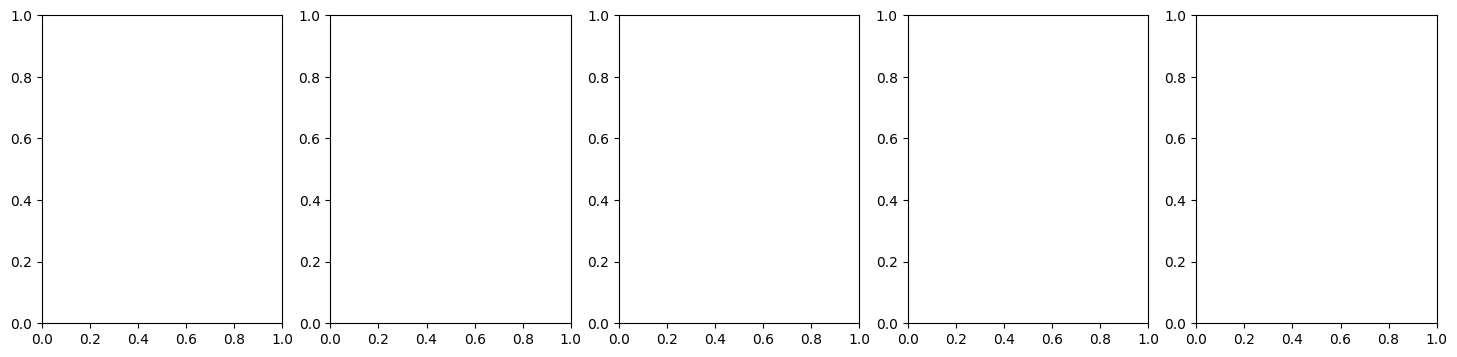

In [30]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
plt.hist(bond_price, color = colors[3], bins=50)
plt.set_ylabel("Frequency Bond Price ")
fig.suptitle("Price Distribution on 2023-01-06")
plt.tight_layout()
plt.show()
   